<a href="https://colab.research.google.com/github/shalsdn01/Fly-AI/blob/1week/05_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MachineLearning

## KNN

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
df = sns.load_dataset("penguins")
df.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


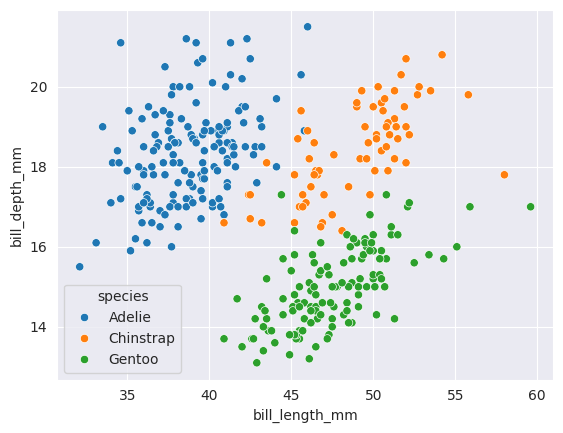

In [ ]:
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
sns.scatterplot(x="bill_length_mm", y="bill_depth_mm",
 data=df, hue="species")
plt.show()

In [ ]:
df = df.dropna(axis=0)
from sklearn.preprocessing import LabelEncoder
import pandas as pd

cols = df.select_dtypes(include=['object']).columns
print(cols)
for col in cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])

df.head()

Index(['species', 'island', 'sex'], dtype='object')


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,1
1,0,2,39.5,17.4,186.0,3800.0,0
2,0,2,40.3,18.0,195.0,3250.0,0
4,0,2,36.7,19.3,193.0,3450.0,0
5,0,2,39.3,20.6,190.0,3650.0,1


In [ ]:
print(df.shape)
train = df.drop('species', axis=1)
target = df['species']
print(train.shape, target.shape)

(333, 7)
(333, 6) (333,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train, target, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(266, 6) (67, 6)
(266,) (67,)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
y_train = y_train.values
X_train[:3, :]

array([[-0.91721936, -0.59372706, -1.75093934,  0.9359428 ,  0.53973681,
        -1.03832798],
       [ 0.52645135, -1.26104283,  0.32310698, -0.719956  , -1.07236416,
        -1.03832798],
       [-0.91721936,  1.09309891, -0.63803644,  1.65589881,  1.40779118,
         0.96308682]])

In [ ]:
X_test = sc.transform(X_test)
y_test = y_test.values

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn.predict(X_test)
print(y_pred)

[1 2 0 1 0 2 2 1 1 1 0 0 2 0 2 0 0 1 0 2 0 0 2 1 0 0 2 2 1 2 1 2 0 0 2 2 1
 2 0 0 0 0 1 1 0 0 2 0 0 2 0 2 2 0 0 2 0 0 1 1 2 2 2 0 0 2 0]


In [ ]:
from sklearn.metrics import *
acc = accuracy_score(y_test, y_pred)
print('accuracy_score : ',acc)
pre = precision_score(y_test, y_pred, average= "macro")
print('precision_score : ', pre)
recall = recall_score(y_test, y_pred, average= "macro")
print('recall_score: ', recall)

accuracy_score :  0.9850746268656716
precision_score :  0.9761904761904763
recall_score:  0.989247311827957


## SVM

In [ ]:
from sklearn import svm, datasets
cancer = datasets.load_breast_cancer()
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
dfX = pd.DataFrame(cancer.data, columns=cancer.feature_names)
dfy = pd.DataFrame(cancer.target, columns=['target'])
print('features :', dfX.shape)
print('label :', dfy.shape)

features : (569, 30)
label : (569, 1)


In [ ]:
df = pd.concat([dfX, dfy], axis=1)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dfX, dfy,
 test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(455, 30) (114, 30)
(455, 1) (114, 1)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
y_train = y_train.values

X_test = sc.transform(X_test)

X_train[:3, :]

array([[-1.44075296, -0.43531947, -1.36208497, -1.1391179 ,  0.78057331,
         0.71892128,  2.82313451, -0.11914956,  1.09266219,  2.45817261,
        -0.26380039, -0.01605246, -0.47041357, -0.47476088,  0.83836493,
         3.25102691,  8.43893667,  3.39198733,  2.62116574,  2.06120787,
        -1.23286131, -0.47630949, -1.24792009, -0.97396758,  0.72289445,
         1.18673232,  4.67282796,  0.9320124 ,  2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167,  1.85197292,  1.319843  ,
         3.42627493,  2.01311199,  2.66503199,  2.1270036 ,  1.55839569,
         0.80531919, -0.81268678,  0.75195659,  0.87716951, -0.89605315,
         1.18122247,  0.18362761,  0.60059598, -0.31771686,  0.52963649,
         2.17331385,  1.3112795 ,  2.08161691,  2.1374055 ,  0.76192793,
         3.26560084,  1.92862053,  2.6989469 ,  1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, -1.10978518, -1.33264483,
        -0.30735463, -0.36555756, -0.69650228,  1

In [ ]:
y_train = y_train.flatten()

In [ ]:
from sklearn.svm import SVC
svc = SVC(kernel="linear")
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_test = y_test.values.flatten()
y_pred = svc.predict(X_test)

In [ ]:
from sklearn.metrics import *
def print_scores(y_true, y_pred):
  print('accuracy_score: {0:.4f}'.format(accuracy_score(y_true, y_pred)))
  print('precision_score: {0:.4f}'.format(precision_score(y_true, y_pred)))
  print('recall_score: {0:.4f}'.format(recall_score(y_true, y_pred)))
print_scores(y_test, y_pred)

accuracy_score: 0.9561
precision_score: 0.9714
recall_score: 0.9577


## Decision Tree

In [ ]:
import pandas as pd
from sklearn import datasets

iris = datasets.load_iris()
dfX = pd.DataFrame(iris.data, columns=iris.feature_names)
dfy = pd.DataFrame(iris.target, columns=['target'])
print('features :', dfX.shape)
print('label :', dfy.shape)

features : (150, 4)
label : (150, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dfX, dfy,
                                                    test_size=0.2, random_state=0)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(120, 4) (30, 4)
(120, 1) (30, 1)


In [ ]:
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values.flatten()
y_test = y_test.values.flatten()

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(120, 4) (30, 4)
(120,) (30,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

시각화 방법
- 텍스트 설명(Export_Text) 출력
- sklearn.tree.plot.tree 메소드와 matplotlib 을 이용해서 의사결정나무 시각화
- 붓꽃 특성 이름을 적용하여 가독성을 높이고 시각화를 개선
- Graphviz

In [ ]:
from sklearn import tree
dtc_model_text = tree.export_text(dtc, feature_names=iris['feature_names'])

print(dtc_model_text)

|--- petal length (cm) <= 2.35
|   |--- class: 0
|--- petal length (cm) >  2.35
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



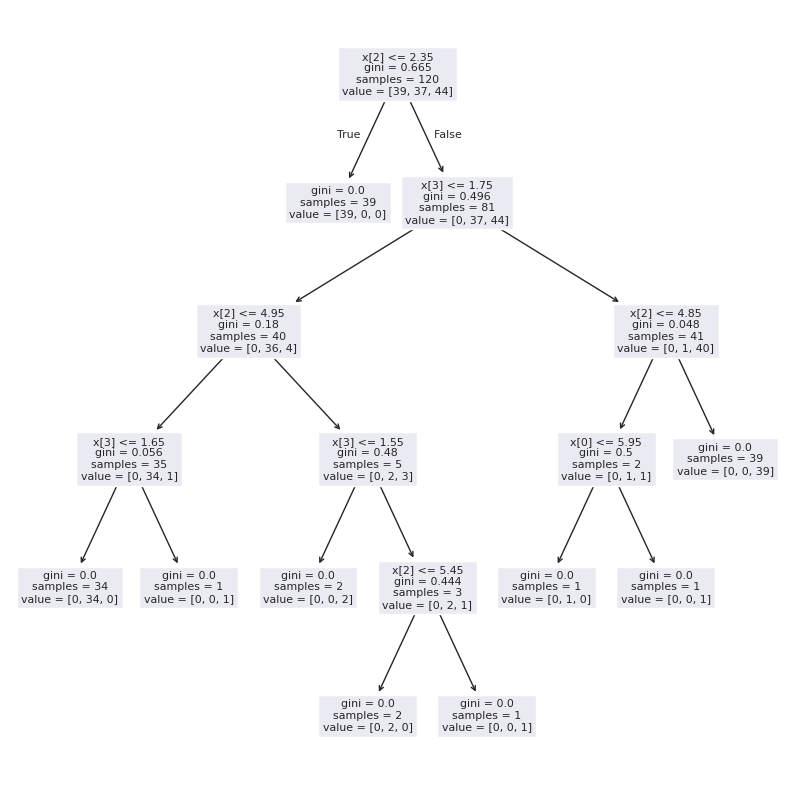

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10, 10))
plot_tree(dtc)
plt.show()

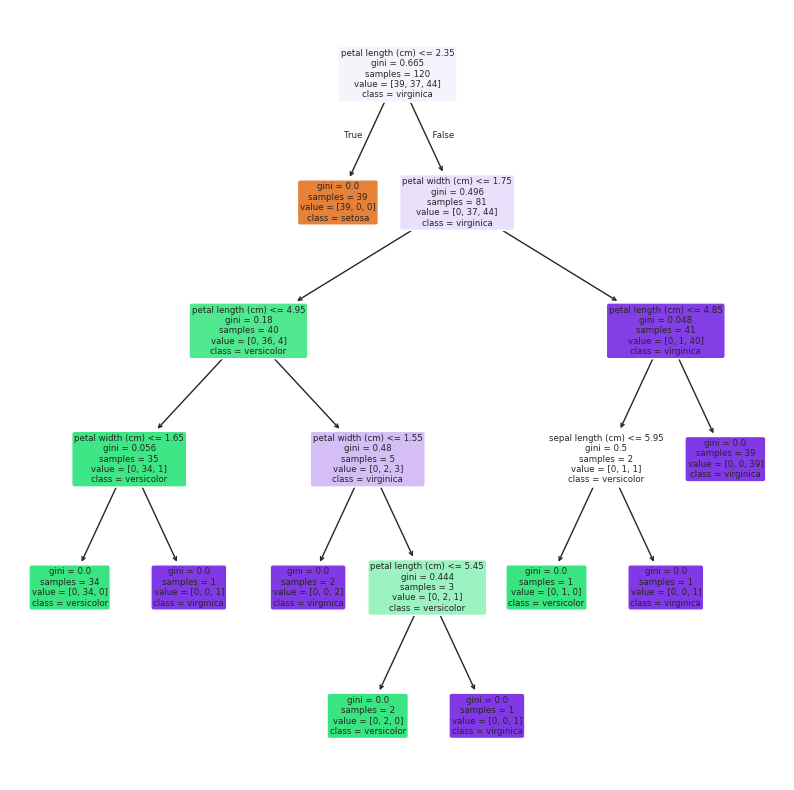

In [ ]:
plt.figure(figsize=(10, 10))
plot_tree(dtc,
          feature_names=iris.feature_names,
          class_names=list(iris.target_names),
          filled=True,
          rounded=True)
plt.show()

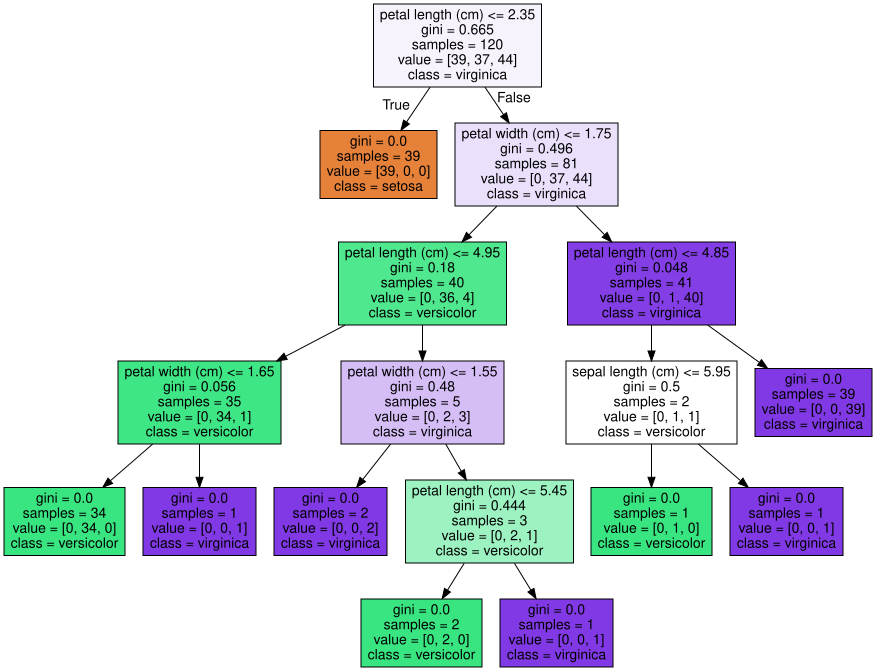

In [ ]:
import graphviz

tree_dot = tree.export_graphviz(
    dtc,
    feature_names=iris.feature_names,
    class_names = iris.target_names,
    filled=True,
    out_file=None
)

dt_graph = graphviz.Source(tree_dot, format='png')
dt_graph

In [ ]:
y_pred = dtc.predict(X_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

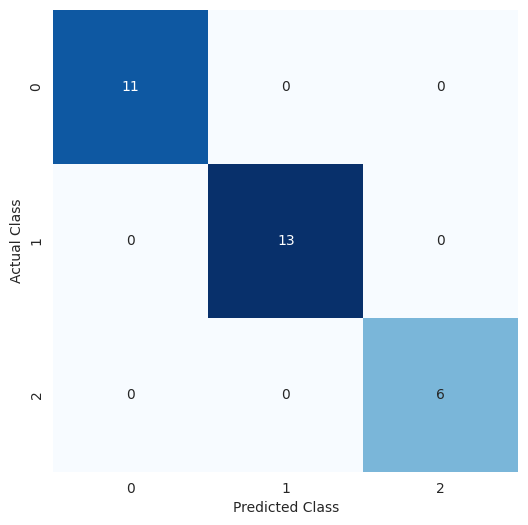

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cf = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(cf, annot=True, fmt='d', cmap="Blues", cbar=False)
ax.set_ylabel('Actual Class')
ax.set_xlabel('Predicted Class')
plt.show()

In [ ]:
from sklearn.metrics import *
def print_scores(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print('accuracy_score  : {0:.4f}'.format(acc))
    pre = precision_score(y_true, y_pred, average="macro")
    print('precision_score : {0:.4f}'.format(pre))
    recall = recall_score(y_true, y_pred, average="macro")
    print('recall_score    : {0:.4f}'.format(recall))

print_scores(y_test, y_pred)

accuracy_score  : 1.0000
precision_score : 1.0000
recall_score    : 1.0000


## RandomForest

In [ ]:
import pandas as pd
df_red = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',sep=';')
df_white = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv',sep=';')

df_red['type'] = "red"
df_white['type'] = "white"

df = pd.concat([df_red, df_white])
df.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [ ]:
df = df.drop_duplicates(keep='last')

df2 = df[df.duplicated(keep='last')]

df3 = df[~df.duplicated(keep='last')]

# print(df1.shape)
print(df2.shape)


(0, 13)


In [ ]:
df['type'] = df["type"].map({'red':0, 'white':1})
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


In [ ]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Train : ', X_train.shape, y_train.shape)
print('Test : ', X_test.shape, y_test.shape)

X_train = X_train.values
y_train = y_train.values
X_test = X_test.values
y_test = y_test.values

Train :  (3724, 12) (3724,)
Test :  (1596, 12) (1596,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score
def print_scores(y_true, y_pred):
  print('accuracy_score: {0:.4f}'.format(accuracy_score(y_true, y_pred)))
  print('precision_score: {0:.4f}'.format(precision_score(y_true, y_pred)))
  print('recall_score: {0:.4f}'.format(recall_score(y_true, y_pred)))

print_scores(y_test, y_pred)

accuracy_score: 0.9956
precision_score: 0.9949
recall_score: 0.9991


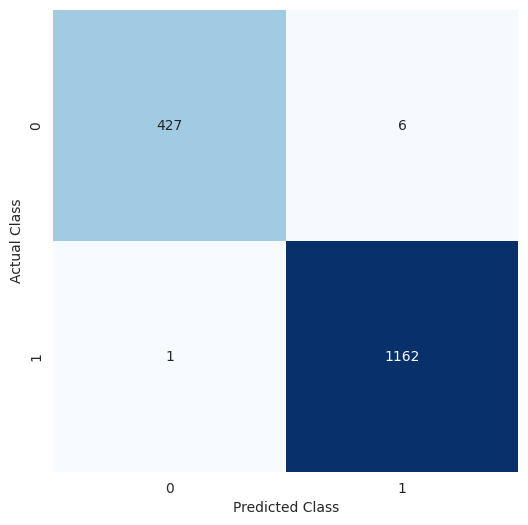

In [ ]:
from sklearn.metrics import confusion_matrix
cfm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
ax = sns.heatmap(cfm, annot=True, fmt='d',cmap="Blues", cbar=False)
ax.set_ylabel('Actual Class')
ax.set_xlabel('Predicted Class')
plt.show()

## K-Means

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/arienugroho050396/Mall-Customer-Segmentation-Unsupervised-ML/refs/heads/main/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
df = sc.fit_transform(df)

In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(df)

KMeans(n_clusters=3)

In [ ]:
df = pd.DataFrame(df, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
pred = model.predict(df)
df['label'] = pred
pred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


array([2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0], dtype=int32)

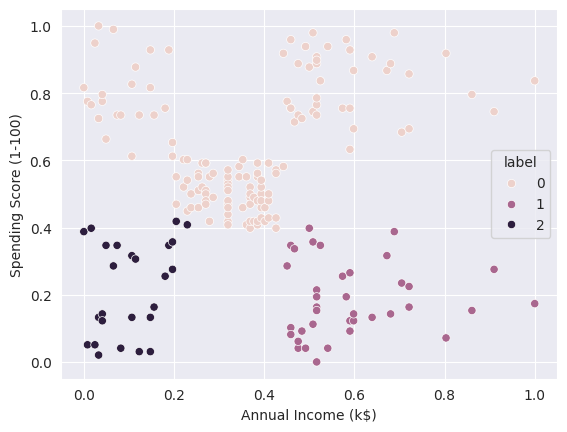

In [ ]:
import seaborn as sns
sns.scatterplot(data=df, x='Annual Income (k$)',
 y='Spending Score (1-100)', hue='label')
plt.show()

In [ ]:
inertia = []
for i in range(1,10):
  model = KMeans(n_clusters= i, init = 'random',random_state=42)
  model.fit(df)
  inertia.append(model.inertia_)

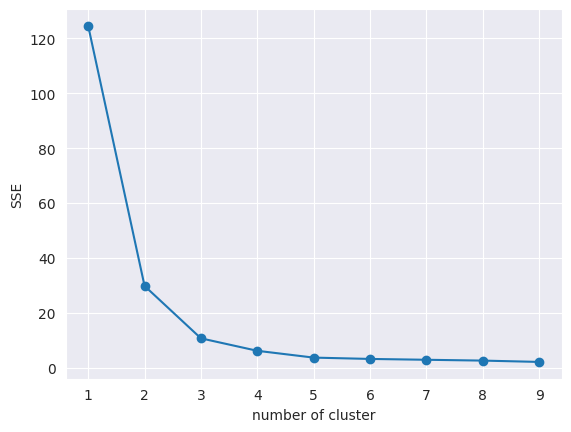

In [ ]:
plt.subplots()
plt.plot(range(1,10),inertia,marker = 'o')
plt.xlabel("number of cluster")
plt.ylabel("SSE")
plt.show()